In [27]:
import numpy as np
import time
import warnings

warnings.filterwarnings("ignore", category=np.ComplexWarning)
np.set_printoptions(formatter={'float': '{: .10e}'.format}, linewidth=1000)

## 1. HE Environment Setup

In [3]:
import sys
import importlib
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import engine.HEdata
import engine.HEengine

importlib.reload(engine.HEdata)
importlib.reload(engine.HEengine)

from engine.HEengine import HEengine
from engine.HEdata import Message, Ciphertext

engine = HEengine()

## 2. Approx invSqrt using Chebyshev Polynomial

In [4]:
def genData(start, middle, end, n):
    a = np.linspace(start, middle, n//2)
    b = np.linspace(middle, end, n//2)
    return np.concatenate((a, b))

In [28]:
def ret_print(x, y, y_eval):
    print("Input\t\t:", x)
    print("Answer\t\t:", y)
    print("Eval ret\t:", y_eval)

    err = y - y_eval
    mre = np.mean(np.abs(err) / np.abs(y))

    print("MRE\t\t:", mre)

--- 63차 체비쇼프 근사 다항식 계수 ---


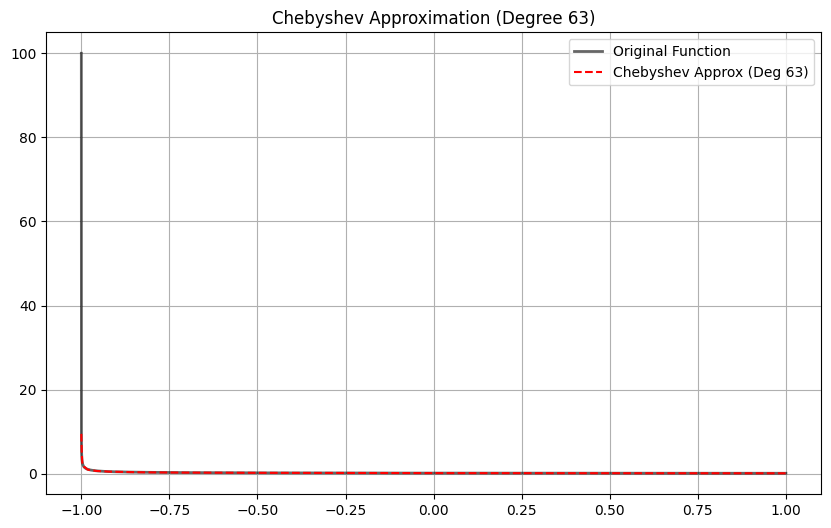


최대 오차 (Max Error): 9.05e-01


(array([-1.0000000000e+00, -9.9999800000e-01, -9.9999600000e-01, ...,  9.9999600000e-01,  9.9999800000e-01,  1.0000000000e+00]),
 array([ 9.9999999998e+01,  7.0710678117e+01,  5.7735026919e+01, ...,  1.0000010000e-01,  1.0000005000e-01,  1.0000000000e-01]),
 array([ 9.4693859487e+00,  9.4597242034e+00,  9.4500724233e+00, ...,  9.9236320438e-02,  9.9229936403e-02,  9.9223535043e-02]),
 array([], dtype=float64))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Chebyshev

def get_chebyshev_approximation(target_func, degree, domain):
    approx_poly = Chebyshev.interpolate(target_func, degree, domain=domain)
    return approx_poly

K = 2 # inverse of K-th root
DOMAIN = [-1, 1]

# 1. 설정
log_deg = 6
degree = 2**log_deg-1

A = 1 * (10 ** -4)
B = 1 * (10 ** 2)

def func(h):
    result = []
    for x in h:
        x = (B-A)*x/2+(B+A)/2
        result.append(pow(x, -1/K))
    return np.array(result)    

# 3. 근사 다항식 생성
cheb_poly = get_chebyshev_approximation(func, degree, DOMAIN)

# 4. 결과 확인 (다항식 계수 출력)
print(f"--- {degree}차 체비쇼프 근사 다항식 계수 ---") 

# 5. 시각화 (원본 vs 근사)
x_vals = np.linspace(DOMAIN[0], DOMAIN[1], 1000000)
y_true = func(x_vals)
y_approx = cheb_poly(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_true, 'k-', label='Original Function', linewidth=2, alpha=0.6)
plt.plot(x_vals, y_approx, 'r--', label=f'Chebyshev Approx (Deg {degree})')

plt.title(f"Chebyshev Approximation (Degree {degree})")
plt.legend()
plt.grid(True)
plt.show()

# 6. 오차 확인
error = np.abs(y_true - y_approx) / y_true
print(f"\n최대 오차 (Max Error): {np.max(error):.2e}")
x_vals, y_true, y_approx, y_approx[y_approx<0]

In [16]:
x = np.concatenate([np.linspace(A, (A+B)/2, 10000000), np.linspace((A+B)/2, B, 10000000)])
y_ans = x**(-1/2)

print(f"X\n{x}\n")

trans_x = x*2/(B-A) - (B+A)/(B-A)
cheb_y = cheb_poly(trans_x)
print("First Approx")
print(cheb_y)
print("#Neg\t\t:", len(cheb_y[cheb_y < 0]))
print()

iter = 10
y_iter = np.copy(cheb_y)

for i in range(iter):
    print("#", i+1)
    y_iter = (3/2) * y_iter - (1/2)*x*(y_iter**3)
    ret_print(x, y_ans, y_iter)
    print("Max RE\t\t:", np.max(np.abs((y_ans-y_iter)/y_ans)), f"({np.argmax(np.abs((y_ans-y_iter)/y_ans))})")
    print()

X
[ 1.0000000000e-04  1.0499999550e-04  1.0999999100e-04 ...  9.9999990000e+01  9.9999995000e+01  1.0000000000e+02]

First Approx
[ 9.4693859487e+00  9.4689026250e+00  9.4684193263e+00 ...  9.9224175959e-02  9.9223855523e-02  9.9223535043e-02]
#Neg		: 0

# 1
Input		: [ 1.0000000000e-04  1.0499999550e-04  1.0999999100e-04 ...  9.9999990000e+01  9.9999995000e+01  1.0000000000e+02]
Answer		: [ 1.0000000000e+02  9.7590009386e+01  9.5346262825e+01 ...  1.0000000500e-01  1.0000000250e-01  1.0000000000e-01]
Eval ret	: [ 1.4161623277e+01  1.4158782336e+01  1.4155942082e+01 ...  9.9990999689e-02  9.9990989816e-02  9.9990979939e-02]
MRE		: 0.0003849325093090112
Max RE		: 0.8583837672338605 (0)

# 2
Input		: [ 1.0000000000e-04  1.0499999550e-04  1.0999999100e-04 ...  9.9999990000e+01  9.9999995000e+01  1.0000000000e+02]
Answer		: [ 1.0000000000e+02  9.7590009386e+01  9.5346262825e+01 ...  1.0000000500e-01  1.0000000250e-01  1.0000000000e-01]
Eval ret	: [ 2.1100428123e+01  2.1089156098e+01  2.1077

In [ ]:
from pathlib import Path

coeff_path = Path("invSqrt_coeffs.py")

try:
    from coeffs.invSqrt_coeffs import _INV_SQRT_COEFFS
    coeffs_dict = dict(_INV_SQRT_COEFFS)
except (ImportError, TypeError, ValueError):
    coeffs_dict = {}

coeffs_dict[degree] = cheb_poly.coef.astype(float).tolist()

lines = ["_INV_SQRT_COEFFS = {"]

for degree in sorted(coeffs_dict):
    coeffs = ", ".join(repr(value) for value in coeffs_dict[degree])
    lines.append(f"    {degree}: [{coeffs}],")

lines.append("}")
lines.append("")

_ = coeff_path.write_text("\n".join(lines), encoding="utf-8")

## 3. Test invSqrt using HEengine

In [19]:
data_num = 100_000
test = genData(A, (A+B)/2, B, data_num)

msg = Message(test, value=B)
msg.to(engine.dt)

ctxt = engine.enc(msg)

x_half = engine.mult(ctxt, 1/2)

x_cheb = engine.mult(ctxt, 2/(B-A))
x_cheb = engine.sub(x_cheb, (B+A)/(B-A))

In [24]:
import importlib

import coeffs.invSqrt_coeffs
import operators.HEapprox

importlib.reload(coeffs.invSqrt_coeffs)
importlib.reload(operators.HEapprox)

from operators.HEapprox import HEStats

stats = HEStats(engine)

In [ ]:
start = time.time()

ret_ctxt = stats.invSqrt(x_half, x_cheb, log_degree=log_deg, iteration=10)

end = time.time()

ret_msg = engine.dec(ret_ctxt)

ret = np.concatenate([
    np.array(ret_msg[i], dtype=np.float64)
    for i in range(len(ret_msg))
])

# Remove padded slots.
ret = ret[:data_num]

ans = test ** (-0.5)
abs_error = np.abs(ans - ret)
rel_error = abs_error / np.abs(ans)

max_idx = np.argmax(rel_error)

print("Max RE\t\t:", rel_error[max_idx], f"({max_idx})")
print("\t\t", ret[max_idx], ans[max_idx])
print("Max AE\t\t:", np.max(abs_error))
print("Mean RE\t\t:", np.mean(rel_error))
print("Time\t\t:", end - start)

Max RE		: 5.076924523152116e-05 (0)
		 100.00507692452314 99.99999999999999
Max AE		: 0.005076924523152115
Mean RE		: 6.041332254037716e-09
Time		: 1.6034257411956787


## 4. Approx

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import chebfit, chebval, Chebyshev

# ============================================================
# 1. Data
# ============================================================

# t_table_1_to_120 = {'alpha_0.2'}

# df = np.arange(1, 121, dtype=np.float64)
# y_true = np.array(t_table_1_to_120["alpha_0.2"], dtype=np.float64)
alpha = 0.025
df = np.arange(1, 2001, dtype=np.float64)
# two-sided alpha
y_true = stats.t.ppf(1.0 - alpha / 2.0, df)


# ============================================================
# 2. Use u = 1 / df
# ============================================================



df_min = 1.0
df_max = 2000.0

u = 1.0 / df
u_min = 1.0 / df_max
u_max = 1.0

# map u in [1/120, 1] to z in [-1, 1]
z = 2.0 * (u - u_min) / (u_max - u_min) - 1.0

print("u range:", u.min(), u.max())
print("z range:", z.min(), z.max())

# ============================================================
# 3. Chebyshev approximation on z ∈ [-1, 1]
# ============================================================

deg = 7

coefs = chebfit(z, y_true, deg=deg)
y_approx = chebval(z, coefs)

abs_err = np.abs(y_true - y_approx)

print("Chebyshev coefficients:")
print(coefs)
print()
print("max abs error :", np.max(abs_err))
print("mean abs error:", np.mean(abs_err))
print("rmse          :", np.sqrt(np.mean(abs_err ** 2)))

# ============================================================
# 4. Plot by df
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(df, y_true, label="Original t-table", linewidth=2)
plt.plot(df, y_approx, "--", label=f"Chebyshev Approx deg={deg}")
plt.xlabel("df")
plt.ylabel("t critical value")
plt.title("Chebyshev approximation: alpha=0.2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 5. Plot error
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(df, abs_err, label="absolute error")
plt.xlabel("df")
plt.ylabel("absolute error")
plt.title(f"Approximation error, degree={deg}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import json
from pathlib import Path

json_path = Path("t_dist_coeffs_by_degree.json")
coeff_path = Path("t_critical_coeffs.py")

with json_path.open("r", encoding="utf-8") as file:
    table = json.load(file)

coeffs_dict = {}

for degree_key, alpha_table in table.items():
    degree = int(degree_key.removeprefix("degree_"))
    coeffs_dict[degree] = {}

    for alpha_key, pairs in alpha_table.items():
        alpha = float(alpha_key.removeprefix("alpha_"))
        coeffs_dict[degree][alpha] = [float(pair[0]) for pair in pairs]

lines = ["_T_CRITICAL_COEFFS = {"]

for degree in sorted(coeffs_dict):
    lines.append(f"    {degree}: {{")

    for alpha in sorted(coeffs_dict[degree], reverse=True):
        coeffs = ", ".join(repr(value) for value in coeffs_dict[degree][alpha])
        lines.append(f"        {alpha}: [{coeffs}],")

    lines.append("    },")

lines.append("}")
lines.append("")

_ = coeff_path.write_text("\n".join(lines), encoding="utf-8")